In [94]:
%matplotlib inline
import os
import numpy as np
from typing import _TypedDict, Dict
import yaml

import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from tampanda import ArmSceneBuilder, RRTStar, GraspPlanner, PickPlaceExecutor
from tampanda.scenes import TABLE_SYMBOLIC_TEMPLATE, BLOCK_SMALL_TEMPLATE
from tampanda.tamp import DomainBridge
from tampanda.symbolic.domains.blocks.blocks_domain import BlocksDomain
from tampanda.planners.grasp_planner import GraspType, GRASP_CONTACT_OFFSET


In [95]:
import os
if "DISPLAY" in os.environ:
    del os.environ["DISPLAY"]
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":3"

In [96]:
# ── Visualisation helpers (provided) ──────────────────────────────────────────
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam
def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img
def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)
def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()
def _table_center():
    try: return ((BOUNDS["min_x"]+BOUNDS["max_x"])/2, (BOUNDS["min_y"]+BOUNDS["max_y"])/2, BOUNDS["table_height"])
    except NameError: return (0.4, 0.4, 0.27)
def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25):
    _show(_render(env, _free_cam(env, _table_center(), distance, azimuth, elevation)), title)
def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center(), distance, 90, -89)), title)
def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)
def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")
print("Visualisation helpers ready ✓")

Visualisation helpers ready ✓


### Setting up TamPanda environment (using ArmsceneBuilder and custom Blocks) from WorkBenchMark yaml problem files
Probably have to rewrite this to adhere to ground truth yaml files from the other WorkBenchMark folder that I just found

[{'name': '4x2_brick_1', 'type': 'brick_4x2', 'color': 'yellow', 'pos': [0.51, -0.1092, 0.0495], 'rotation': [0, 0, 0]}, {'name': '2x2_brick_2', 'type': 'brick_2x2', 'color': 'red', 'pos': [0.3882, -0.1099, 0.0495], 'rotation': [0, 0, 0]}, {'name': '2x2_brick_3', 'type': 'brick_2x2', 'color': 'green', 'pos': [0.2631, -0.1105, 0.0495], 'rotation': [0, 0, 0]}]
[0.51, -0.1092, 0.0495]
[0.3882, -0.1099, 0.0495]
[0.2631, -0.1105, 0.0495]
{'min_x': np.float64(-0.09999999999999998), 'max_x': np.float64(0.9), 'min_y': np.float64(0.20000000000000007), 'max_y': np.float64(1.2000000000000002), 'table_height': np.float64(0.27)}
0.5
0.5
[0.51, -0.1092, 0.0495]
[0.3882, -0.1099, 0.0495]
[0.2631, -0.1105, 0.0495]


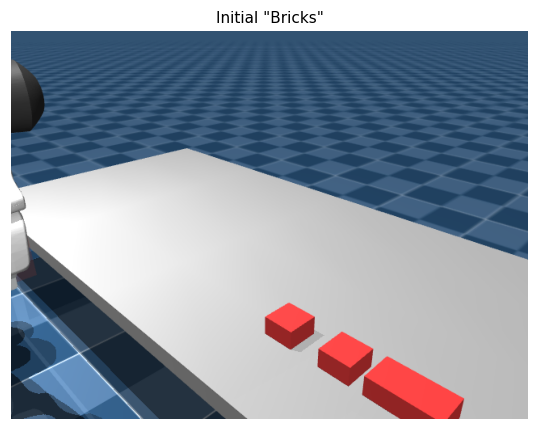

In [ ]:

with open('dataset/ground_truth/tier2/task_069.yaml', 'r') as file:
    yaml_content = file.read()


product_data = yaml.safe_load(yaml_content)
blocks_info = product_data.get('initial_blocks', [])

print(blocks_info)


builder = ArmSceneBuilder()
builder.add_resource("table", TABLE_SYMBOLIC_TEMPLATE)
#TODO: Check workbenchmark Tier 1 and 2 regarding other potential block types
builder.add_resource("block_2x2", "block_templates/brick_2x2.xml") 
builder.add_resource("block_4x2", "block_templates/brick_4x2.xml") 

builder.add_object("table", name="table", pos=[0.0, 0.4, 0.0], quat=[0.0, 0.0, 0.0, 1.0])





for i, brick in enumerate(blocks_info):
    block_name = brick['name']
    if brick['type'] == 'brick_2x2':
        builder_name = "block_2x2"
    elif brick['type'] == 'brick_4x2':
        builder_name = "block_4x2"
    else:
        builder_name = "block_2x2"
        print("Warning: Block type not known!")

    # init_pos = [START_X + (i * SPACING), START_Y, Z_DROP]
    init_pos = brick['pos']
    print(init_pos)
    builder.add_object(builder_name, name=block_name, pos=init_pos, quat=[1.0, 0.0, 0.0, 0.0])

env = builder.build_env(rate=200.0)

domain = BlocksDomain(env.model, table_geom_name="table_surface", working_area=(1,1))
BOUNDS = domain.get_working_bounds()
print(BOUNDS)
table_height = BOUNDS["table_height"]
table_center_x = (BOUNDS["max_x"]-BOUNDS["min_x"])/2
table_center_y = (BOUNDS["max_y"]-BOUNDS["min_y"])/2
print(table_center_x)
print(table_center_y)
    
if len(blocks_info) > 0:
    first_block_name = blocks_info[0]['name']
    BLOCK_HALF = env.get_object_half_size(first_block_name)
    
    for i, brick in enumerate(blocks_info):
        block_name = brick['name']
        print(brick['pos'])
        init_x = table_center_x + brick['pos'][0] 
        init_y = table_center_y + brick['pos'][1]
        init_z = table_height + brick['pos'][2]
        
        env.set_object_pose(block_name, np.array([init_x, init_y, init_z]))

env.reset_velocities()
env.forward()
env.rest(0.5)

show_scene(env, "Initial \"Bricks\"")